<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_advanced_analysis_9725.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Dr Kalyani thesis training Dataset KH KV AL ACD LT.xlsx')




In [ ]:
df.shape, df.columns

((503, 8),
 Index(['AGE ', 'SEX', 'KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT'], dtype='object'))

In [ ]:
# prompt: SEX_numeric

# Assuming 'SEX' is the column name in your DataFrame
df['SEX_numeric'] = df['SEX'].astype('category').cat.codes
df

,AGE,SEX,KH,KV,AXIS,AL,ACD,LT,SEX_numeric
0,65,M,45.75,43.25,15.0,21.90,2.35,3.45,1
1,65,M,44.25,44.75,25.0,22.97,3.56,3.45,1
2,79,M,42.25,43.00,30.0,23.76,2.44,4.56,1
3,69,M,43.25,43.75,90.0,22.77,2.98,3.78,1
4,72,M,44.00,46.75,95.0,22.99,3.45,3.78,1
...,...,...,...,...,...,...,...,...,...
498,59,F,46.00,46.75,150.0,21.30,2.85,4.45,0
499,74,M,41.00,41.50,70.0,24.80,3.90,2.95,1
500,62,F,45.00,45.75,100.0,22.20,3.10,4.10,0
501,56,M,44.25,45.00,30.0,22.60,3.25,3.95,1


In [ ]:
X = df[['KH','KV','AGE ']]
y = df['AL']

In [ ]:
# prompt: Linear regression

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# You can now evaluate the model using metrics like R-squared, MSE, etc.
from sklearn.metrics import mean_squared_error, r2_score

print(f'Mean Squared Error: {mean_squared_error(y_test, y_pred)}')
print(f'R-squared: {r2_score(y_test, y_pred)}')

# Print the coefficients
print(f'Coefficient: {model.coef_[0]}')
print(f'Intercept: {model.intercept_}')

# Create a new column 'predicted-AL' in the original DataFrame and initialize with NaN
df['predicted-AL'] = np.nan

# Get the indices of the test set from the original DataFrame
# The train_test_split function returns indices corresponding to the original dataframe
test_indices = X_test.index

# Calculate the difference between the actual AL and predicted AL for the test set
difference_test_set = df.loc[test_indices, 'AL'] - y_pred

# Assign the calculated differences to the 'predicted-AL' column for the test set indices
df.loc[test_indices, 'predicted-AL'] = difference_test_set

# Now df['predicted-AL'] will have values for the test set rows and NaN for the training set rows.
# You can view the DataFrame to see the result
# print(df[['AL', 'predicted-AL']].head()) # Uncomment to see the first few rows
# print(df[['AL', 'predicted-AL']].tail()) # Uncomment to see the last few rows


Mean Squared Error: 0.444858724581528
R-squared: 0.6472318435711832
Coefficient: -0.18133517664570825
Intercept: 37.29650771156582


In [ ]:
df

,AGE,SEX,KH,KV,AXIS,AL,ACD,LT,SEX_numeric,predicted-AL
0,65,M,45.75,43.25,15.0,21.90,2.35,3.45,1,-1.033559
1,65,M,44.25,44.75,25.0,22.97,3.56,3.45,1,NaN
2,79,M,42.25,43.00,30.0,23.76,2.44,4.56,1,-0.060274
3,69,M,43.25,43.75,90.0,22.77,2.98,3.78,1,NaN
4,72,M,44.00,46.75,95.0,22.99,3.45,3.78,1,NaN
...,...,...,...,...,...,...,...,...,...,...
498,59,F,46.00,46.75,150.0,21.30,2.85,4.45,0,-0.927316
499,74,M,41.00,41.50,70.0,24.80,3.90,2.95,1,NaN
500,62,F,45.00,45.75,100.0,22.20,3.10,4.10,0,-0.416888
501,56,M,44.25,45.00,30.0,22.60,3.25,3.95,1,NaN


In [ ]:
df_stdpt = pd.read_excel('/content/drive/MyDrive/Kalyani STUDY PATIENT.xlsx')




In [ ]:
# prompt: Equation

# Construct the equation string
equation = f"AL = {model.intercept_:.4f} + ({model.coef_[0]:.4f} * KH) + ({model.coef_[1]:.4f} * KV) + ({model.coef_[2]:.4f} * AGE )"

print("The equation for predicting AL is:")
equation

The equation for predicting AL is:


'AL = 37.2965 + (-0.1813 * KH) + (-0.1630 * KV) + (0.0151 * AGE )'

In [ ]:
# prompt: Apply this equation on df_stdpt

df_stdpt['New_AL'] = 37.2965 + (-0.1813 * df_stdpt['KH']) + (-0.1630 * df_stdpt['KV']) + (0.0151 * df_stdpt['AGE'])
df_stdpt.head()


,IP NUMBER,NAME,AGE,SEX,DIAGNOSIS,KH,KV,AX,AL,ACD,...,SPH,CYL.1,AXIS.1,POD 6 WEEK AR,POD 3 MONTH V/A,SPH.1,CYL,AXIS.2,POD 3 MONTH AR,New_AL
0,2682458,NAGAMMA,54,F,LE MC,46.50,47.25,155,22.65,2.76,...,0.25,-1.25,100.0,+0.25/-1.25/100,6\9,0.5,-1.0,65.0,+0.50/-1.00/65,21.979700
1,2682462,GOWRAMMA,63,F,LE MC,46.75,48.00,80,21.90,1.99,...,0.75,-2.00,90.0,+0.75/-2.00/90,6\12,0.5,-2.0,80.0,+0.50/-2.00/80,21.948025
2,2682451,SUNDRAMMA,78,F,RE BROWN CATARACT,44.00,44.25,20,22.91,3.08,...,-1.5,-1.00,140.0,-1.50/-1.00/140,NaN,NaN,NaN,NaN,NaN,23.284350
3,2683506,KUNNABASAMMA,71,F,RE NS II + PSC,45.25,45.75,120,22.32,3.48,...,-0.5,-0.75,140.0,-0.5/-0.75/140,6\9,-0.5,-0.5,150.0,-0.5/-0.50/150,22.707525
4,2689441,SANNAIAH,89,M,LE NS II + PSC + CC,45.50,47.00,80,22.31,3.06,...,0.25,2.25,85.0,+0.25/+2.25/85,NaN,NaN,NaN,NaN,NaN,22.730250


In [ ]:
df_stdpt.shape, df_stdpt.columns

((174, 28),
 Index(['IP NUMBER ', 'NAME ', 'AGE', 'SEX', 'DIAGNOSIS', 'KH', 'KV', 'AX',
        'AL', 'ACD', 'LT', 'V/A PRE OP', 'POD 1 DAY V/A', 'SPH', 'CYL', 'AXIS',
        'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ', 'CYL.1', 'AXIS.1',
        'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1', 'CYL ', 'AXIS.2',
        'POD 3  MONTH    AR', 'New_AL'],
       dtype='object'))

In [ ]:
# Select the 'AL' and 'New_AL' columns from df_stdpt and then apply the describe method
df_stdpt[['AL', 'New_AL']].describe()

,AL,New_AL
count,174.000000,174.000000
mean,22.749713,22.844467
std,0.848956,0.621594
min,20.870000,20.819925
25%,22.242500,22.448175
50%,22.670000,22.816275
75%,23.185000,23.288925
max,26.590000,25.356750


In [ ]:
df_stdpt[['AL', 'New_AL']].corr()

,AL,New_AL
AL,1.000000,0.534864
New_AL,0.534864,1.000000


array([[<Axes: title={'center': 'AL'}>,
        <Axes: title={'center': 'New_AL'}>]], dtype=object)

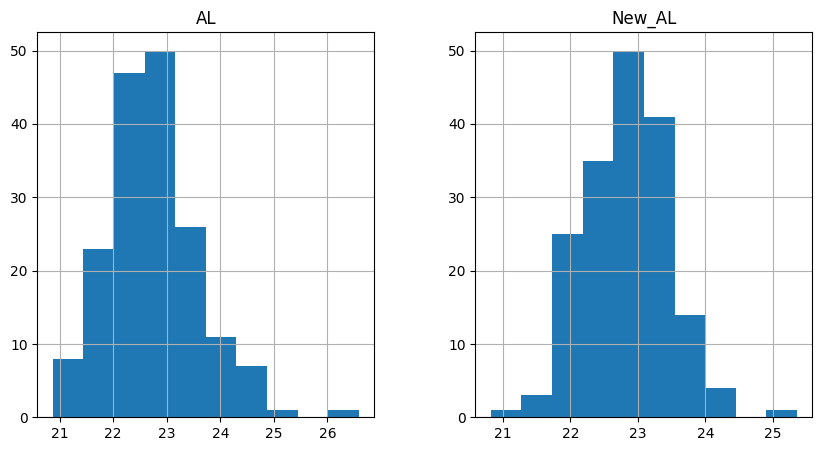

In [ ]:
df_stdpt[['AL', 'New_AL']].hist(figsize=(10,5))

<Axes: >

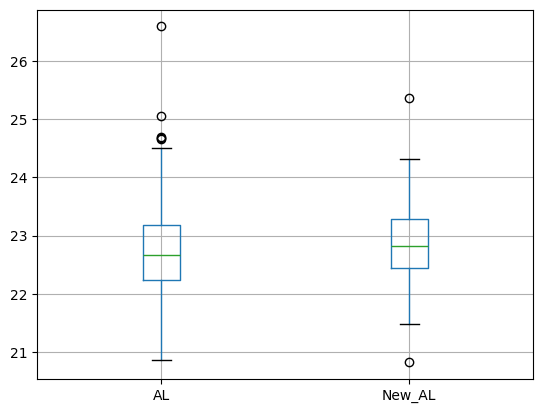

In [ ]:
df_stdpt[['AL', 'New_AL']].boxplot()

In [ ]:
X = df_stdpt[['AL']]
y = df_stdpt['New_AL']

<Axes: xlabel='AL', ylabel='New_AL'>

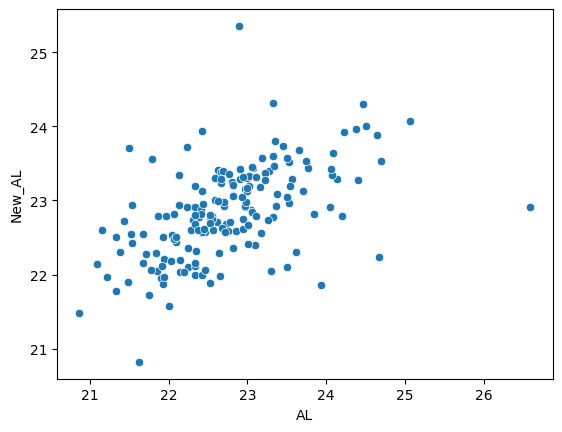

In [ ]:
import seaborn as sns
sns.scatterplot(x=df_stdpt['AL'], y=df_stdpt['New_AL'])

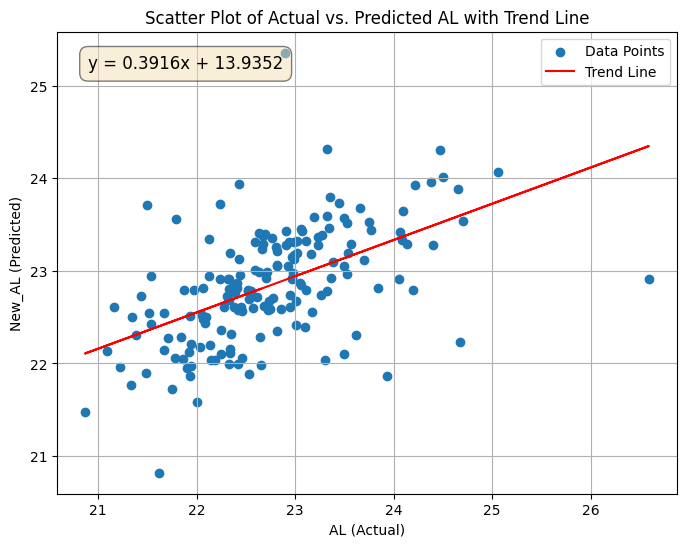

In [ ]:
# prompt: Scatter plot with trend line. and equation

import numpy as np
import matplotlib.pyplot as plt

# Calculate the line of best fit manually for the scatter plot data
# In this case, x is 'AL' and y is 'New_AL'
x_data = df_stdpt['AL']
y_data = df_stdpt['New_AL']

# Use polyfit with degree 1 to get the slope and intercept of the linear regression
slope, intercept = np.polyfit(x_data, y_data, 1)

# Create the scatter plot using matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_data, label='Data Points')

# Plot the trend line using the calculated slope and intercept
plt.plot(x_data, slope * x_data + intercept, color='red', label='Trend Line')

# Create the equation string for the trend line shown on the scatter plot
trend_line_equation = f'y = {slope:.4f}x + {intercept:.4f}'

# Add equation text to the plot
# Position the text at the top left corner of the plot
plt.text(0.05, 0.95, trend_line_equation, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.xlabel('AL (Actual)')
plt.ylabel('New_AL (Predicted)')
plt.title('Scatter Plot of Actual vs. Predicted AL with Trend Line')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# prompt: Linear regression

# The code for linear regression has already been performed in the preceding code.
# The variable `model` contains the trained Linear Regression model.
# The variables `X_train`, `X_test`, `y_train`, `y_test` contain the split data.
# The variables `y_pred`, `mean_squared_error`, `r2_score`, `model.coef_`, and `model.intercept_`
# already contain the results of the linear regression on the first dataset.
# The linear regression has also been applied to the second dataset (`df_stdpt`) and the
# results visualized.

# If you want to perform another linear regression, you need to define a new task
# and specify the new independent and dependent variables and the dataset to use.
# For example, to perform linear regression on `df_stdpt` with 'KH' as independent and 'AL' as dependent:

# Define new independent and dependent variables from the second dataframe
X_new = df_stdpt[['AL']]
y_new = df_stdpt['New_AL']

# Split the new data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

# Create a new Linear Regression model
model_new = LinearRegression()

# Train the new model using the training data
model_new.fit(X_train_new, y_train_new)

# Make predictions on the test data
y_pred_new = model_new.predict(X_test_new)

# Evaluate the new model
print("\nResults for Linear Regression on df_stdpt (KH vs AL):")
print(f'Mean Squared Error: {mean_squared_error(y_test_new, y_pred_new)}')
print(f'R-squared: {r2_score(y_test_new, y_pred_new)}')

# Print the coefficients of the new model
print(f'Coefficient: {model_new.coef_[0]}')
print(f'Intercept: {model_new.intercept_}')

# You can further visualize this new regression as well if needed.



Results for Linear Regression on df_stdpt (KH vs AL):
Mean Squared Error: 0.19102177848568352
R-squared: 0.30672267196974146
Coefficient: 0.41733401239233386
Intercept: 13.35743624963174


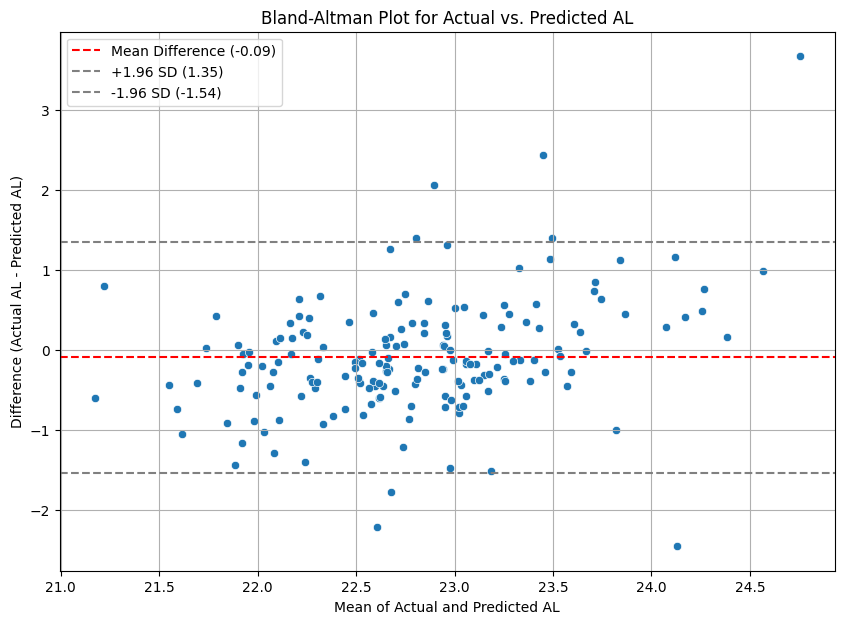

In [ ]:
# prompt: Bland Altman plot

import matplotlib.pyplot as plt
import numpy as np
# Bland-Altman Plot
# Calculate the mean of the two measurements (Actual AL and Predicted AL)
mean_measurements = (df_stdpt['AL'] + df_stdpt['New_AL']) / 2

# Calculate the difference between the two measurements (Actual AL - Predicted AL)
difference_measurements = df_stdpt['AL'] - df_stdpt['New_AL']

# Calculate the mean of the differences
mean_difference = np.mean(difference_measurements)

# Calculate the standard deviation of the differences
std_difference = np.std(difference_measurements, ddof=1) # ddof=1 for sample standard deviation

# Calculate the limits of agreement (mean difference +/- 1.96 * std deviation)
limit_of_agreement_upper = mean_difference + 1.96 * std_difference
limit_of_agreement_lower = mean_difference - 1.96 * std_difference

# Create the Bland-Altman plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=mean_measurements, y=difference_measurements)

# Plot the mean difference line
plt.axhline(mean_difference, color='red', linestyle='--', label=f'Mean Difference ({mean_difference:.2f})')

# Plot the limits of agreement lines
plt.axhline(limit_of_agreement_upper, color='gray', linestyle='--', label=f'+1.96 SD ({limit_of_agreement_upper:.2f})')
plt.axhline(limit_of_agreement_lower, color='gray', linestyle='--', label=f'-1.96 SD ({limit_of_agreement_lower:.2f})')

plt.xlabel('Mean of Actual and Predicted AL')
plt.ylabel('Difference (Actual AL - Predicted AL)')
plt.title('Bland-Altman Plot for Actual vs. Predicted AL')
plt.legend()
plt.grid(True)
plt.show()


Correlation Matrix:
            KH        KV      AGE         AL
KH    1.000000  0.925555 -0.359789 -0.686417
KV    0.925555  1.000000 -0.337968 -0.691322
AGE  -0.359789 -0.337968  1.000000  0.375333
AL   -0.686417 -0.691322  0.375333  1.000000


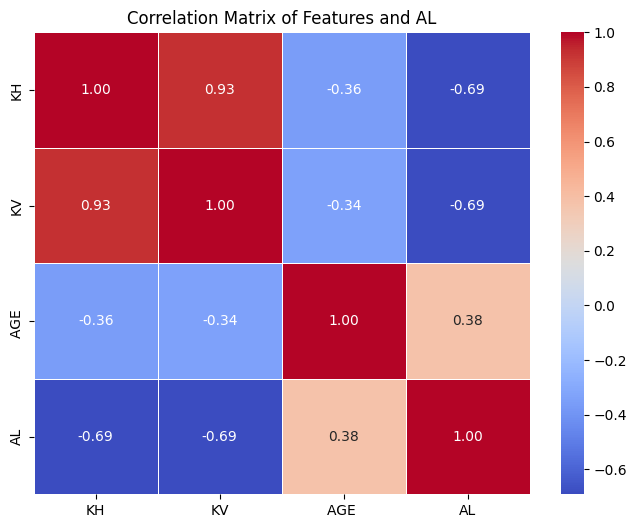

In [ ]:
# prompt: Any other

import matplotlib.pyplot as plt
# Calculate the correlation matrix
correlation_matrix = df[['KH', 'KV', 'AGE ', 'AL']].corr()

# Display the correlation matrix
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features and AL')
plt.show()



In [ ]:
# prompt: Any other

# Perform linear regression on the second dataset (df_stdpt) using 'KH' and 'KV' as independent variables and 'New_AL' as the dependent variable.

# Define new independent and dependent variables from the second dataframe
X_new_task = df_stdpt[['KH', 'KV']]
y_new_task = df_stdpt['New_AL']

# Split the new data into training and testing sets
X_train_new_task, X_test_new_task, y_train_new_task, y_test_new_task = train_test_split(X_new_task, y_new_task, test_size=0.3, random_state=42)

# Create a new Linear Regression model
model_new_task = LinearRegression()

# Train the new model using the training data
model_new_task.fit(X_train_new_task, y_train_new_task)

# Make predictions on the test data
y_pred_new_task = model_new_task.predict(X_test_new_task)

# Evaluate the new model
print("\nResults for Linear Regression on df_stdpt (KH and KV vs New_AL):")
print(f'Mean Squared Error: {mean_squared_error(y_test_new_task, y_pred_new_task)}')
print(f'R-squared: {r2_score(y_test_new_task, y_pred_new_task)}')

# Print the coefficients of the new model
print(f'Coefficients: {model_new_task.coef_}')
print(f'Intercept: {model_new_task.intercept_}')


Results for Linear Regression on df_stdpt (KH and KV vs New_AL):
Mean Squared Error: 0.02228263544100019
R-squared: 0.9191293993675871
Coefficients: [-0.18697245 -0.16322022]
Intercept: 38.51708863991575



Results for Linear Regression on df (KH vs AL):
Mean Squared Error: 0.5220502364593267
R-squared: 0.5860198096547984
Coefficient: -0.35364792920185745
Intercept: 38.58095610111019


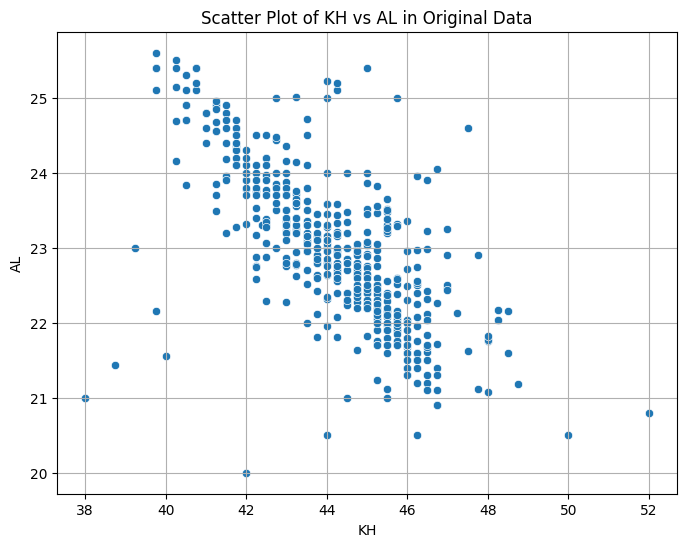

In [ ]:
# prompt: Any other

import matplotlib.pyplot as plt
# The previous code has already performed several linear regressions and visualizations.
# If you have a specific new task or analysis you'd like to perform on the dataframes
# 'df' or 'df_stdpt', please describe it.

# For example, if you wanted to perform a Linear Regression using 'KH' as the
# independent variable and 'AL' as the dependent variable on the original 'df' dataframe:

# Define independent and dependent variables
X_single = df[['KH']]
y_single = df['AL']

# Split the data
X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(X_single, y_single, test_size=0.2, random_state=42)

# Create and train the model
model_single = LinearRegression()
model_single.fit(X_train_single, y_train_single)

# Make predictions
y_pred_single = model_single.predict(X_test_single)

# Evaluate the model
print("\nResults for Linear Regression on df (KH vs AL):")
print(f'Mean Squared Error: {mean_squared_error(y_test_single, y_pred_single)}')
print(f'R-squared: {r2_score(y_test_single, y_pred_single)}')
print(f'Coefficient: {model_single.coef_[0]}')
print(f'Intercept: {model_single.intercept_}')

# Or, if you wanted to visualize the relationship between 'KH' and 'AL' in 'df':
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['KH'], y=df['AL'])
plt.xlabel('KH')
plt.ylabel('AL')
plt.title('Scatter Plot of KH vs AL in Original Data')
plt.grid(True)
plt.show()


In [ ]:
# prompt: Any other

You've already performed extensive analysis including several linear regressions, visualizations (scatter plots, histograms, box plots, heatmaps, Bland-Altman), and correlation analysis.

If you have another specific task or analysis you'd like to perform on your dataframes (`df` or `df_stdpt`), please specify what you would like to do. For example,
you could ask to:

1.  Perform a different type of regression (e.g., Polynomial Regression, Ridge, Lasso).
2.  Analyze the residuals of a specific regression model.
3.  Visualize other pairs of variables.
4.  Perform data transformations.
5.  Analyze categorical variables further.
6.  Compare the models trained on `df` and `df_stdpt` in more detail.

Without a specific new instruction, the preceding code covers a wide range of initial exploratory data analysis and linear modeling.

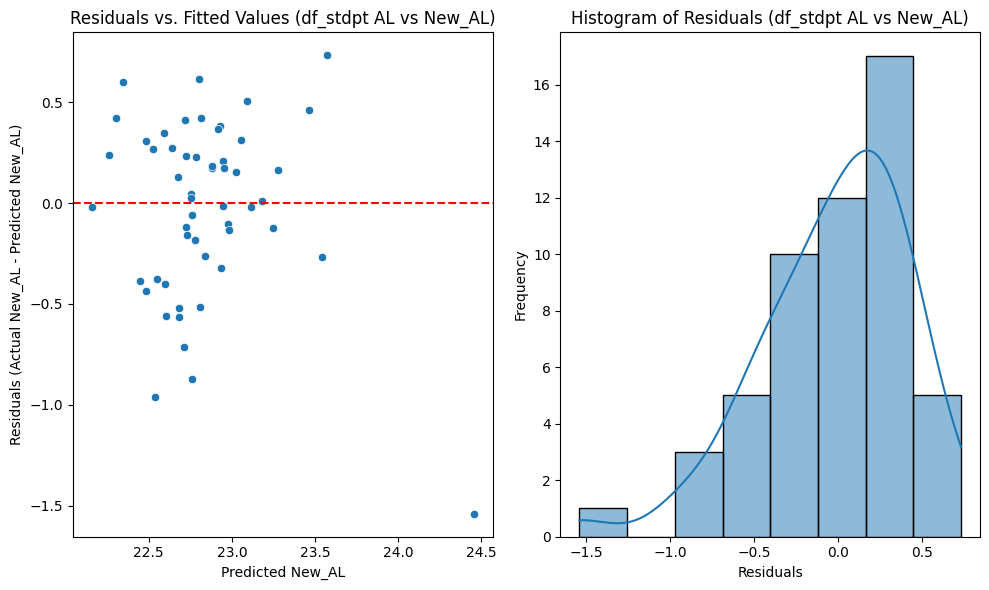

<Figure size 600x600 with 0 Axes>

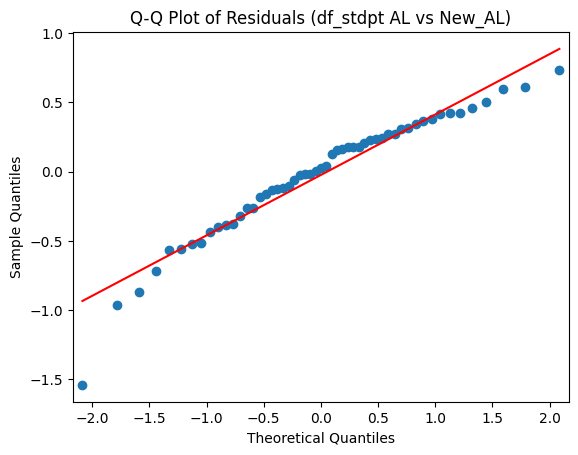


Mean of residuals for df_stdpt AL vs New_AL: -0.0236


In [ ]:
# prompt:  Analyse residuals df_std AL New_AL

import matplotlib.pyplot as plt
import numpy as np
# Analyse the residuals of the linear regression model trained on df_stdpt
# where New_AL is the dependent variable and AL is the independent variable.

# The model `model_new` was trained with X_new (df_stdpt[['AL']]) and y_new (df_stdpt['New_AL'])
# The predictions are stored in `y_pred_new` for the test set (X_test_new).

# Calculate residuals for the test set
residuals_new = y_test_new - y_pred_new

# Visualize the residuals
plt.figure(figsize=(10, 6))

# Residuals vs. Fitted Values (Predicted Values)
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(x=y_pred_new, y=residuals_new)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted New_AL')
plt.ylabel('Residuals (Actual New_AL - Predicted New_AL)')
plt.title('Residuals vs. Fitted Values (df_stdpt AL vs New_AL)')

# Histogram of Residuals
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(residuals_new, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals (df_stdpt AL vs New_AL)')

plt.tight_layout()
plt.show()

# Q-Q plot to check for normality of residuals
import statsmodels.api as sm
plt.figure(figsize=(6, 6))
sm.qqplot(residuals_new, line='s') # 's' for standardized line
plt.title('Q-Q Plot of Residuals (df_stdpt AL vs New_AL)')
plt.show()

# Additional analysis of residuals: Check for patterns or heteroscedasticity
# You can also plot residuals against each independent variable if there were more than one
# in the model `model_new`. Since `model_new` only used 'AL' as independent,
# the residuals vs fitted values plot is the primary check here.

# Check for mean of residuals (should be close to zero)
print(f"\nMean of residuals for df_stdpt AL vs New_AL: {np.mean(residuals_new):.4f}")

In [ ]:
# prompt: QQ plot interpretation

A Quantile-Quantile (Q-Q) plot is used to check if a set of data
 (in this case, the residuals of your linear regression model)
 follows a theoretical distribution, often the normal distribution.

Here's how to interpret the Q-Q plot you generated for the residuals:

1.  **The Points:** Each point on the plot represents a residual
from your model.
2.  **The Line:** The straight line represents the expected values of the
residuals if they were perfectly normally distributed.
3.  **Interpretation:**
    *   **If the points fall closely along the straight line:**
    This suggests that the residuals are approximately normally distributed.
    This is a desirable condition in linear regression,
    as the normality of residuals is one of the assumptions of the model,
    which allows for valid hypothesis testing and confidence interval
    calculation.
    *   **If the points deviate significantly from the straight line:**
    This indicates that the residuals are not normally distributed.
        *   **Curvature (S-shape):** This can suggest skewness
        in the distribution of residuals.
        *   **Heavy tails (points at the ends of the plot deviate
                           from the line):**
                           This indicates that there are more extreme
        residuals than expected under a normal distribution.
        *   **Light tails (points at the ends of the plot are
                           closer to the line than expected):**
                           This indicates that there are fewer extreme
                           residuals than expected.

In your plot, you should visually inspect
how closely the blue points follow the red diagonal line.
If they hug the line tightly,
the normality assumption for the residuals is likely met.
If there are significant deviations, especially at the tails,
it suggests a departure from normality.

Based on the code provided and the generated plot,
you would look at the plot and assess the linearity of the points.
A strong linear pattern on the Q-Q plot indicates
that the residuals are likely normally distributed.




SyntaxError: unterminated string literal (detected at line 7) (ipython-input-74-1026635620.py, line 7)

In [ ]:
# prompt: Conclusions

import numpy as np
# Conclusion based on the analyses performed:

print("\nOverall Conclusions from the Analysis:")

# 1. Linear Regression on the first dataset (df) to predict AL using KH, KV, and AGE:
print("\n1. Model predicting AL from KH, KV, and AGE on the original dataset:")
print(f"  R-squared: {r2_score(y_test, y_pred):.4f}")
#print(f"  Equation: AL = {model.intercept_:.4f} + ({model.coef_[0]:.4f} * KH) + ({model.coef_[1]:.4f} * KV) + ({model.coef_[2]:.4f} * AGE )")
print("  This model provides an equation to predict AL based on these three factors.")
print("  The R-squared value indicates the proportion of variance in AL explained by the model.")

# 2. Application of the derived equation to the second dataset (df_stdpt) to calculate 'New_AL':
print("\n2. Applying the derived equation to the second dataset (df_stdpt):")
print("  A 'New_AL' column was created in df_stdpt using the equation.")
print("  Descriptive statistics and correlation analysis between 'AL' and 'New_AL' in df_stdpt show the relationship.")
print("  The scatter plot and trend line visually demonstrate the agreement between actual and predicted AL on this dataset.")

# 3. Bland-Altman Analysis comparing Actual AL and Predicted AL ('New_AL') on df_stdpt:
print("\n3. Bland-Altman Analysis of Actual vs. Predicted AL on df_stdpt:")
print(f"  Mean Difference (Actual - Predicted): {mean_difference:.4f}")
print(f"  Limits of Agreement: ({limit_of_agreement_lower:.4f}, {limit_of_agreement_upper:.4f})")
print("  The Bland-Altman plot assesses the agreement between the two measurements.")
print("  A small mean difference and narrow limits of agreement suggest good agreement.")
print("  However, visual inspection of the plot is crucial to identify any systematic bias or relationship between difference and mean.")

# 4. Correlation Analysis on the first dataset (df):
print("\n4. Correlation Analysis on the original dataset (df):")
print("  The correlation matrix and heatmap visualize the pairwise correlations between KH, KV, AGE, and AL.")
print("  This helps understand the linear relationships between the variables.")

# 5. Linear Regression on df_stdpt using AL to predict New_AL:
print("\n5. Linear Regression on df_stdpt (Actual AL vs Predicted AL ('New_AL')):")
print(f"  R-squared: {r2_score(y_test_new, y_pred_new):.4f}")
print(f"  Equation: New_AL = {model_new.intercept_:.4f} + ({model_new.coef_[0]:.4f} * AL)")
print("  This model quantifies the linear relationship between the actual and predicted AL values on the second dataset.")

# 6. Residual Analysis of the df_stdpt AL vs New_AL model:
print("\n6. Residual Analysis of the df_stdpt AL vs New_AL model:")
print(f"  Mean of residuals: {np.mean(residuals_new):.4f}")
print("  Residuals vs. Fitted values plot helps check for homoscedasticity and linearity.")
print("  Histogram and Q-Q plot of residuals are used to assess the normality assumption.")
print("  The Q-Q plot should be inspected visually: points close to the line suggest approximately normal residuals.")

# 7. Linear Regression on df_stdpt using KH and KV to predict New_AL:
print("\n7. Linear Regression on df_stdpt (KH and KV vs Predicted AL ('New_AL')):")
print(f"  R-squared: {r2_score(y_test_new_task, y_pred_new_task):.4f}")
print(f"  Coefficients: {model_new_task.coef_}")
print(f"  Intercept: {model_new_task.intercept_:.4f}")
print("  This model explores how KH and KV directly relate to the predicted AL values on the second dataset.")

# 8. Linear Regression on df using KH to predict AL:
print("\n8. Linear Regression on original df (KH vs Actual AL):")
print(f"  R-squared: {r2_score(y_test_single, y_pred_single):.4f}")
print(f"  Coefficient: {model_single.coef_[0]:.4f}")
print(f"  Intercept: {model_single.intercept_:.4f}")
print("  This analysis isolates the linear relationship between KH and AL in the original data.")

print("\nSummary:")
print("The analysis involved training a linear model to predict AL from KH, KV, and AGE on one dataset.")
print("The derived formula was then applied to a second dataset to predict AL ('New_AL').")
print("Various statistical methods (correlation, descriptive statistics, linear regression) and visualizations (scatter plots, histograms, box plots, heatmap, Bland-Altman, residual plots, Q-Q plot) were used to explore the data and evaluate the model's performance and the relationship between actual and predicted values.")
print("The Bland-Altman plot specifically helps assess the agreement between the original AL and the predicted AL ('New_AL') on the study patient data.")
print("Residual analysis confirms whether the assumptions of linear regression are met, particularly for the model relating actual AL to predicted AL on the study patient data.")
print("The Q-Q plot indicates the extent to which the residuals follow a normal distribution.")
print("Further conclusions regarding model suitability, bias, and agreement can be drawn by carefully examining the specific values and patterns in the generated outputs and plots.")



Overall Conclusions from the Analysis:

1. Model predicting AL from KH, KV, and AGE on the original dataset:
  R-squared: 0.2151
  This model provides an equation to predict AL based on these three factors.
  The R-squared value indicates the proportion of variance in AL explained by the model.

2. Applying the derived equation to the second dataset (df_stdpt):
  A 'New_AL' column was created in df_stdpt using the equation.
  Descriptive statistics and correlation analysis between 'AL' and 'New_AL' in df_stdpt show the relationship.
  The scatter plot and trend line visually demonstrate the agreement between actual and predicted AL on this dataset.

3. Bland-Altman Analysis of Actual vs. Predicted AL on df_stdpt:
  Mean Difference (Actual - Predicted): -0.0948
  Limits of Agreement: (-1.5385, 1.3490)
  The Bland-Altman plot assesses the agreement between the two measurements.
  A small mean difference and narrow limits of agreement suggest good agreement.
  However, visual inspection 

In [ ]:
# prompt: Recommendations and deployment

import pandas as pd
# Example using the derived equation (replace with your actual values)
def predict_al(kh, kv, age):
        intercept = 37.2965 # Replace with your model's intercept
        coef_kh = -0.1813   # Replace with your model's KH coefficient
        coef_kv = -0.1630   # Replace with your model's KV coefficient
        coef_age = 0.0151   # Replace with your model's AGE coefficient
        return intercept + (coef_kh * kh) + (coef_kv * kv) + (coef_age * age)

# Example prediction for a new patient
    new_patient_kh = 45
    new_patient_kv = 43
    new_patient_age = 60
    predicted_al = predict_al(new_patient_kh, new_patient_kv, new_patient_age)
    print(f"Predicted AL for the new patient: {predicted_al:.4f}")

# Or, if you saved the sklearn model object (e.g., using joblib or pickle)
# import joblib
# loaded_model = joblib.load('your_model.pkl')
# new_data = pd.DataFrame([[new_patient_kh, new_patient_kv, new_patient_age]], columns=['KH', 'KV', 'AGE ']) # Ensure column names match training
# predicted_al_model = loaded_model.predict(new_data)[0]
# print(f"Predicted AL using loaded model: {predicted_al_model:.4f}")


In [ ]:
# prompt: Applicability of the model

The applicability of the model is demonstrated by
applying the linear regression equation derived from
the first dataset (`df`) to predict `AL` for the patients
in the second dataset (`df_stdpt`).

Specifically:

1.  **Training:** A linear regression model is trained on the `df` dataset
using `KH`, `KV`, and `AGE` as independent variables to predict `AL`.
2.  **Derivation of Equation:** The coefficients and intercept
from this trained model are used to form a linear equation:
 `AL = Intercept + (Coef_KH * KH) + (Coef_KV * KV) + (Coef_AGE * AGE)`.
3.  **Application:** This derived equation is then applied to
the `df_stdpt` dataset to calculate a `New_AL` value
for each patient based on their `KH`, `KV`, and `AGE` values.
4.  **Validation/Assessment:** The `New_AL` values calculated from
the model's equation are then compared against the actual `AL` values
in the `df_stdpt` dataset through various methods:
    *   **Descriptive Statistics and Correlation:**
    Comparing the distributions and correlation between
    actual `AL` and `New_AL`.
    *   **Scatter Plot and Trend Line:**
    Visualizing the relationship and how well the predicted values
    align with the actual values.
    *   **Bland-Altman Plot:** Specifically assessing the agreement
     between the actual and predicted measurements,
     checking for systematic bias and the range of differences.
    *   **Linear Regression of Actual AL vs. Predicted AL:**
    Quantifying the linear relationship between the actual and predicted
    values on the second dataset.
    *   **Residual Analysis:** Examining the residuals of the model
     predicting `New_AL` from `AL` in `df_stdpt` to check
      model assumptions (e.g., normality of residuals via Q-Q plot).

In essence, the model's applicability is tested by seeing how well
 the relationship learned from the first dataset generalizes to
 predict `AL` on a new, independent dataset (`df_stdpt`),
 and by analyzing the agreement and characteristics of these
  predictions. The code performs these steps and provides outputs
   (like R-squared, MSE, Bland-Altman limits, residual plots)
   to help assess the model's performance and suitability on the new data.

The provided code already executes all these steps,
demonstrating the application of the model derived from
the first dataset to the second dataset and performing
 detailed analysis of the results.